# Project 3: Monte Carlo Techniques
## Neutron Transport and Scattering Through a Shielding Layer
**Project:** Computational physics Monte Carlo study  
Anonymised version

### Introduction

This notebook develops a Monte Carlo simulation for thermal neutrons moving through shielding slabs. The physical events included in the code are free flight, absorption, isotropic scattering, reflection from the entrance side of the slab and transmission through the far side. Since each neutron history is random, the useful quantities are not individual paths but probabilities estimated from many simulated neutrons.

The code is organised in the same order as the model is built. It first checks the random sampling tools: uniform random numbers, three-dimensional random points, exponential free paths and isotropic directions. It then converts the tabulated microscopic cross-sections for water, lead and graphite into macroscopic cross-sections. These quantities are used in simulate_single_neutron_newer for path visualisation and in simulate_many_neutrons_vectorized for repeated probability estimates. The final sections scan slab thickness, fit effective attenuation lengths from transmission probabilities, and use a Woodcock tracking method for two adjacent slabs.

## 1.1 Validation of the uniform random number generator

The first code section tests numpy.random.uniform() directly. Three independent sets of 1000 random numbers are generated over the interval [0,1] and plotted using 50 histogram bins. Since the histograms are plotted as densities, the expected uniform probability density is 1.

The dotted guide lines show the approximate one-standard-deviation fluctuation expected from a finite sample. With 1000 samples and 50 bins, the mean number of entries per bin is 20, so visible bin-to-bin fluctuations are expected even when the generator is behaving correctly.

In [49]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

import pandas as pd

from mpl_toolkits.mplot3d import Axes3D

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import time
start_time = time.perf_counter()

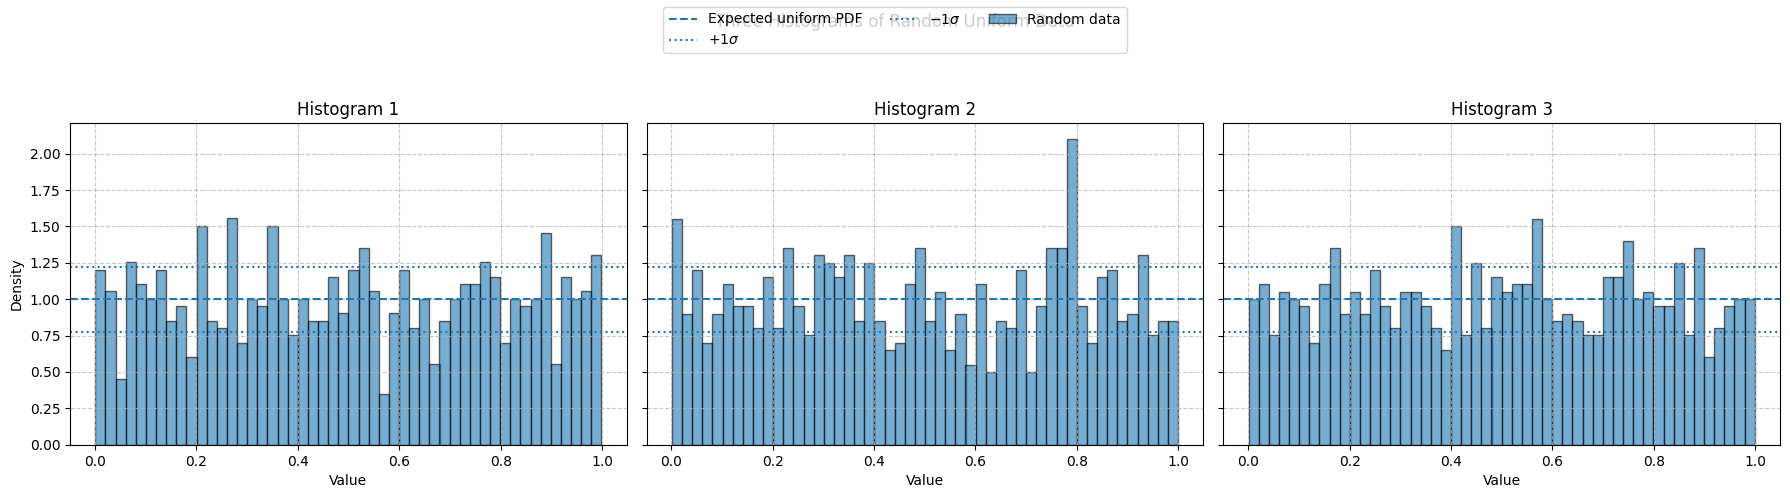

In [50]:
# Generate random data
sample_size = 1000
num_bins = 50

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, ax in enumerate(axes):
    x = np.random.uniform(0, 1, sample_size)

    counts, bin_edges = np.histogram(x, bins=num_bins, density=True)

    # calculate bin centers for plotting
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    mean_count = sample_size / num_bins
    std_count = np.sqrt(mean_count)

    ax.bar(
        bin_centers,
        counts,
        width=1 / num_bins,
        alpha=0.6,
        edgecolor="black",
        label="Random data"
    )

    # Expected uniform PDF over [0, 1] is 1
    ax.axhline(1, linestyle="--", label="Expected uniform PDF")
    ax.axhline((mean_count + std_count) / mean_count,
               linestyle=":", label=r"$+1\sigma$")
    ax.axhline((mean_count - std_count) / mean_count,
               linestyle=":", label=r"$-1\sigma$")

    ax.set_title(f"Histogram {i + 1}")
    ax.set_xlabel("Value")
    ax.grid(True, linestyle="--", alpha=0.7)

axes[0].set_ylabel("Density")

# 只放一个总 legend，避免重复
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.suptitle("Three Histograms of Random Uniform Data")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

The three histograms fluctuate around the expected density of 1 without a systematic trend across the interval. This is consistent with a uniform random number generator. The size of the fluctuations is also reasonable: with only 1000 samples split into 50 bins, each bin contains a finite random count, so a perfectly flat histogram would not be expected.

This result supports the use of numpy.random.uniform() as the base random number generator for the rest of the notebook. Since the exponential free paths, isotropic directions and Monte Carlo outcome decisions are all generated from uniform samples, this validation is the first check that the later simulation will not be biased by an obviously non-uniform source.

## 1.2 Random points in three dimensions and spectral testing

The next code cell compares two three-dimensional random point generators in the same interactive Plotly figure. The left plot uses numpy.random.uniform() to generate 3000 independent points in the unit cube. A reliable generator should fill the cube without visible planes or repeated geometric structure.

The right plot uses the RANDSSP multiplicative congruential generator to generate 1500 triples. This is included as a spectral test: a poor generator can look acceptable in one dimension but show correlations when successive random numbers are grouped as x, y and z coordinates.

In [51]:
# -----------------------------
# First plot: numpy.random.uniform()
# -----------------------------
N_points = 3000

x = np.random.uniform(0, 1, N_points)
y = np.random.uniform(0, 1, N_points)
z = np.random.uniform(0, 1, N_points)

# -----------------------------
# Second plot: RANDSSP
# -----------------------------
def randssp(p, q):
    # RANDSSP multiplicative congruential uniform random number generator
    # Based on the parameters used by IBM's Scientific Subroutine Package

    m = 2**31
    a = 2**16 + 3
    c = 0
    x = 123456789

    r = np.zeros((p, q))

    for l in range(q):
        for k in range(p):
            x = (a * x + c) % m
            r[k, l] = x / m

    return r

spectra = randssp(3, 1500)

# -----------------------------
# Create two side-by-side 3D subplots
# -----------------------------
fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=(
        "Random points generated using numpy.random.uniform()",
        "RANDSSP Spectral Test"
    )
)

# Add the numpy.random.uniform() scatter plot on the left
fig.add_trace(
    go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode="markers",
        marker=dict(
            size=3,
            opacity=0.5,
            color="blue"
        ),
        name="numpy.random.uniform()"
    ),
    row=1,
    col=1
)

# Add the RANDSSP scatter plot on the right
fig.add_trace(
    go.Scatter3d(
        x=spectra[0, :],
        y=spectra[1, :],
        z=spectra[2, :],
        mode="markers",
        marker=dict(
            size=3,
            color="red",
            opacity=0.65
        ),
        name="RANDSSP"
    ),
    row=1,
    col=2
)

# Configure the layout and the two 3D scenes
fig.update_layout(
    title="3D Scatter Comparison",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z",
        aspectmode="cube"
    ),
    scene2=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z",
        aspectmode="cube"
    ),
    margin=dict(l=0, r=0, t=60, b=0),
    showlegend=False
)

fig.show()

The NumPy points fill the cube much more smoothly, while the RANDSSP points show visible structure. This indicates a spectral issue in RANDSSP: successive generated values are correlated and do not behave like independent three-dimensional samples.

The conclusion from this comparison is that RANDSSP is not suitable for the neutron transport calculation. If a generator produced artificial planes or correlations in three-dimensional samples, the random walk could inherit artificial preferred directions. Therefore, the later simulation uses NumPy's generator instead.

## 1.3 Exponential random number generator and attenuation length for water

The function sample_exponential(mean_free_path, size) uses inverse-transform sampling. If u is a uniform random number in (0,1), then

$$
x = -\lambda \ln(u)
$$

is exponentially distributed with mean free path \lambda. For the absorption-only water test, the code first calculates the macroscopic absorption cross-section

$$
\Sigma_a = n\sigma_a,
$$

and the theoretical absorption length

$$
\lambda = \frac{1}{\Sigma_a}.
$$

For water, the code gives \Sigma_a = 0.02224 cm^{-1}, so the theoretical absorption-only attenuation length is 44.97 cm. The simulation then generates 10 independent sets of 10000 absorption depths, bins them into 30 bins from 0 to 10\lambda, and fits the averaged binned counts.

Taking the logarithm of the binned counts gives

$$
\ln N(x) = C - \frac{x}{\lambda},
$$

so a weighted linear polyfit gives the attenuation length from the fitted slope. Empty bins and bins with zero uncertainty are removed before the fit.

In [52]:
def sample_exponential(mean_free_path, size=None):
    """
    Sample from an exponential distribution using the inverse transform method.

    Parameters:
    - mean_free_path: The mean free path (scale parameter) of the exponential distribution.
    - size: The number of samples to generate. If None, a single sample is returned.

    Returns:
    - An array of samples drawn from the exponential distribution.
    """
    # Generate uniform random numbers in the range (0, 1)
    u = np.random.uniform(0, 1, size)

    # Apply the inverse transform sampling formula for the exponential distribution
    samples = -mean_free_path * np.log(u)

    return samples

In [53]:
def material_properties(rho, M, sigma_a, sigma_s):
    """
    Calculate material properties: number density, macroscopic absorption cross-section, and attenuation length.

    Parameters:
    - rho: Density of the material (g/cm^3)
    - M: Molar mass of the material (g/mol)
    - sigma_a: Microscopic absorption cross-section (barn)
    - sigma_s: Microscopic scattering cross-section (barn)

    Returns:
    - n: Number density (atoms/cm^3)
    - Sigma_a: Macroscopic absorption cross-section (cm^-1)
    - lambda_att: Absorption-only attenuation length (cm)
    """
    AVOGADRO = 6.022e23  # mol^-1
    BARN = 1e-24          # cm^2

    # Molecular number density
    n = rho * AVOGADRO / M

    # Macroscopic absorption cross-section
    Sigma_a = n * sigma_a * BARN

    # Macroscopic scattering cross-section
    Sigma_s = n * sigma_s * BARN

    # Absorption-only attenuation length
    lambda_att = 1.0 / Sigma_a

    return n, Sigma_a, Sigma_s, lambda_att

In [54]:
# Water data from Table 1
rho_water = 1.00           # g cm^-3
M_water = 18.0153          # g mol^-1
sigma_a_water = 0.6652     # barn
sigma_s_water = 103.0      # barn

# Calculate properties for water
n_water, Sigma_a_water, Sigma_s_water, lambda_water = material_properties(rho_water, M_water, sigma_a_water, sigma_s_water)

print(f"Number density of water = {n_water:.3e} cm^-3")
print(f"Macroscopic absorption cross-section = {Sigma_a_water:.5f} cm^-1")
print(f"Macroscopic scattering cross-section = {Sigma_s_water:.5f} cm^-1")
print(f"Theoretical attenuation length = {lambda_water:.2f} cm")

Number density of water = 3.343e+22 cm^-3
Macroscopic absorption cross-section = 0.02224 cm^-1
Macroscopic scattering cross-section = 3.44300 cm^-1
Theoretical attenuation length = 44.97 cm


In [55]:
# Parameters for the attenuation length test
num_iterations = 10
num_particles = 10000
num_bins = 30
r_cutoff = 10.0 * lambda_water

frequency = np.zeros((num_iterations, num_bins))

for i in range(num_iterations):
    absorption_depths = sample_exponential(lambda_water, num_particles)

    counts, bin_edges = np.histogram(
        absorption_depths,
        bins=num_bins,
        range=(0, r_cutoff)
    )

    frequency[i, :] = counts

bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

mean_freq = np.mean(frequency, axis=0)
std_freq = np.std(frequency, axis=0, ddof=1)

# Remove empty bins and bins with zero uncertainty
valid = (mean_freq > 0) & (std_freq != 0)

x_fit = bin_centres[valid]
mean_freq_fit = mean_freq[valid]
std_freq_fit = std_freq[valid]

log_mean_freq = np.log(mean_freq_fit)
error_log_freq = std_freq_fit / mean_freq_fit

fit, covariance = np.polyfit(
    x_fit,
    log_mean_freq,
    1,
    w=1.0 / error_log_freq,
    cov=True
)

slope = fit[0]
intercept = fit[1]

slope_error = np.sqrt(covariance[0, 0])

lambda_fit = -1.0 / slope
lambda_error = slope_error / slope**2

print(f"Fitted attenuation length = {lambda_fit:.2f} ± {lambda_error:.2f} cm")
print(f"Theoretical attenuation length = {lambda_water:.2f} cm")

Fitted attenuation length = 45.01 ± 0.12 cm
Theoretical attenuation length = 44.97 cm


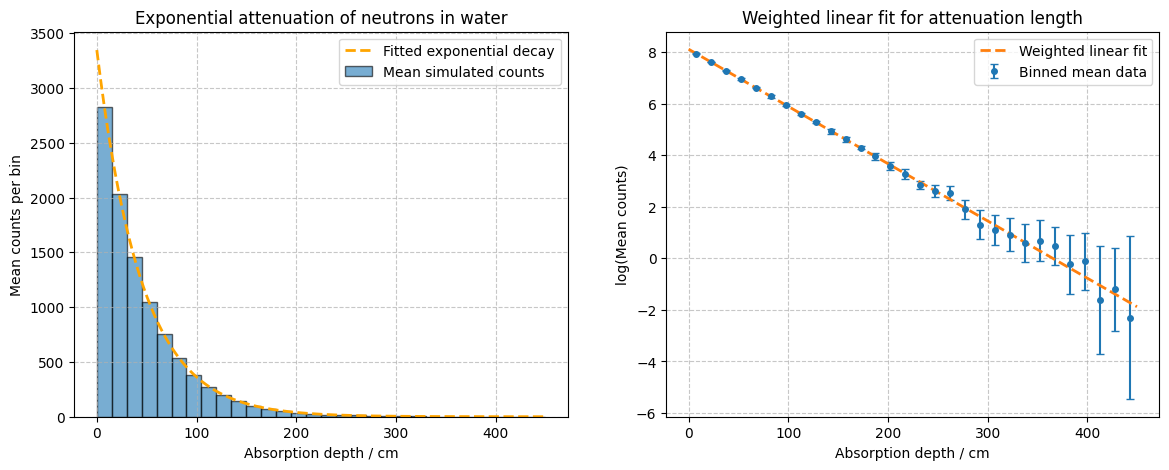

In [56]:
# Plot the averaged binned absorption depths and the fitted exponential curve

x_curve = np.linspace(0, r_cutoff, 500)
fit_curve = np.exp(intercept + slope * x_curve)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(
    bin_centres,
    mean_freq,
    width=bin_width,
    alpha=0.6,
    edgecolor="black",
    label="Mean simulated counts"
)

#plt.errorbar(
#    bin_centres,
#    mean_freq,
#    yerr=std_freq,
#   fmt="none",
#   capsize=3,
#   label="Standard deviation",
#   color="red"
#)

axes[0].plot(
    x_curve,
    fit_curve,
    linestyle="--",
    linewidth=2,
    label="Fitted exponential decay",
    color="orange"
)

axes[0].set_xlabel("Absorption depth / cm")
axes[0].set_ylabel("Mean counts per bin")
axes[0].set_title("Exponential attenuation of neutrons in water")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.7)

# Plot the weighted linear fit to log(mean counts)

axes[1].errorbar(
    x_fit,
    log_mean_freq,
    yerr=error_log_freq,
    fmt="o",
    markersize=4,
    capsize=3,
    label="Binned mean data"
)

axes[1].plot(
    x_curve,
    intercept + slope * x_curve,
    linestyle="--",
    linewidth=2,
    label="Weighted linear fit"
)

axes[1].set_xlabel("Absorption depth / cm")
axes[1].set_ylabel("log(Mean counts)")
axes[1].set_title("Weighted linear fit for attenuation length")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.7)
plt.show()

The fitted attenuation length is 45.01 +- 0.12 cm, compared with the theoretical value of 44.97 cm. The agreement is well within the fitted uncertainty, which shows that the inverse-transform exponential sampler is working correctly for the absorption-only case.

The semi-log plot is also close to linear over the fitted range, as expected for exponential attenuation. This validates the weighted fitting procedure that is later reused for transmission through scattering slabs.

## 1.4 Isotropic unit vector generator

The function isotropic_unit_vectors(size) generates random directions on the surface of a unit sphere. The code samples the azimuthal angle $\phi$ uniformly between 0 and $2\pi$, and samples $\cos\theta$ uniformly between -1 and 1. Sampling $\theta$ itself uniformly would overpopulate the poles, so using $\cos\theta$ is the correct isotropic choice.

The Cartesian components are calculated as

$$
x = \sin\theta\cos\phi,\qquad
y = \sin\theta\sin\phi,\qquad
z = \cos\theta.
$$

The following plot generates 3000 such vectors and displays them as a point cloud on the unit sphere. A visually uniform coverage of the sphere supports the use of this function for scattering directions in the path-visualisation part of the notebook.

In [57]:
def isotropic_unit_vectors(size):
    phi = np.random.uniform(0, 2 * np.pi, size)
    costheta = np.random.uniform(-1, 1, size)
    theta = np.arccos(costheta)
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = costheta
    return x, y, z

In [58]:
x,y,z = isotropic_unit_vectors(3000)

fig = go.Figure(data=[go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode="markers",
    marker=dict(size=3, color='green', opacity=0.5)
)])
fig.update_layout(title='Validation of isotropic unit vector generation (Interactive 3D)',
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z',
        aspectmode='cube'
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)
fig.show()

The generated points lie on the surface of a sphere and do not visibly cluster around the poles or equator. This is the expected behaviour for isotropic scattering. Since scattering in the later model assumes no preferred outgoing direction, this visual check supports the use of isotropic_unit_vectors for the full path visualisation.

### 1.5 Isotropic random steps with exponentially distributed lengths

The function isotropic_steps(mean_free_path, size) combines the previous two sampling tools. It samples a step length from the exponential distribution and multiplies it by an isotropic unit vector:

$$
\Delta \vec{r} = s\hat{u}.
$$

In the demonstration cell, 3000 steps are generated using lambda_water as the scale length. The three-panel figure checks the generated displacement vectors, the histogram of step lengths up to 5 lambda_water, and the standardised directions dx/s, dy/s and dz/s. The standardised directions should lie on a unit sphere, confirming that the step-length sampling and direction sampling are being combined correctly.

In [59]:
def isotropic_steps(mean_free_path, size):
    """
    Generate isotropic random steps with exponentially distributed lengths.

    Parameters:
    - mean_free_path: The mean free path (scale parameter) for the exponential distribution of step lengths.
    - size: The number of steps to generate.
    Returns:
    - dx, dy, dz: Arrays of step components in x, y, z directions.
    - step_lengths: Array of the lengths of each step.
    """
    step_lengths = sample_exponential(mean_free_path, size)
    x_dir, y_dir, z_dir = isotropic_unit_vectors(size)

    dx = step_lengths * x_dir
    dy = step_lengths * y_dir
    dz = step_lengths * z_dir

    return dx, dy, dz, step_lengths

In [60]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

num_steps = 3000

dx, dy, dz, step_lengths = isotropic_steps(lambda_water, num_steps)

num_bins = 50
r_max = 5.0 * lambda_water

counts, bin_edges = np.histogram(
    step_lengths,
    bins=num_bins,
    range=(0, r_max)
)

bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

dx_standardized = dx / step_lengths
dy_standardized = dy / step_lengths
dz_standardized = dz / step_lengths

fig = make_subplots(
    rows=1,
    cols=3,
    specs=[
        [{"type": "scene"}, {"type": "xy"}, {"type": "scene"}]
    ],
    subplot_titles=[
        "Isotropic random steps",
        "Distribution of step lengths",
        "Standardized step directions"
    ]
)

# -------------------------
# First plot: interactive 3D scatter
# -------------------------
fig.add_trace(
    go.Scatter3d(
        x=dx,
        y=dy,
        z=dz,
        mode="markers",
        marker=dict(
            size=3,
            opacity=0.5
        ),
        name="Step displacements"
    ),
    row=1,
    col=1
)

# -------------------------
# Second plot: histogram / bar chart
# -------------------------
fig.add_trace(
    go.Bar(
        x=bin_centres,
        y=counts,
        width=bin_width,
        opacity=0.6,
        marker=dict(
            line=dict(width=1)
        ),
        name="Generated step lengths"
    ),
    row=1,
    col=2
)

# -------------------------
# Third plot: interactive 3D scatter
# -------------------------
fig.add_trace(
    go.Scatter3d(
        x=dx_standardized,
        y=dy_standardized,
        z=dz_standardized,
        mode="markers",
        marker=dict(
            size=3,
            opacity=0.5
        ),
        name="Standardized directions"
    ),
    row=1,
    col=3
)

fig.update_layout(
    title="Isotropic random steps with exponentially distributed lengths",
    width=1500,
    height=550,
    margin=dict(l=0, r=0, t=80, b=0),
    showlegend=False,

    scene=dict(
        xaxis_title="Step displacement in x / cm",
        yaxis_title="Step displacement in y / cm",
        zaxis_title="Step displacement in z / cm",
        aspectmode="cube"
    ),

    scene2=dict(
        xaxis_title="dx / step length",
        yaxis_title="dy / step length",
        zaxis_title="dz / step length",
        aspectmode="cube"
    )
)

fig.update_xaxes(
    title_text="Step length / cm",
    row=1,
    col=2
)

fig.update_yaxes(
    title_text="Counts per bin",
    row=1,
    col=2
)

fig.show()

The step-length histogram decreases rapidly with distance, as expected for an exponential distribution. Most sampled steps are short, while long free paths are possible but less common. The standardised direction plot remains distributed over the unit sphere, showing that multiplying by the exponential step length has not introduced a preferred direction.

This confirms that the code can generate the two ingredients needed for neutron random walks: random interaction distances and random post-scattering directions.

## 2.1 Determining material properties

The function material_properties converts the table values into quantities used by the transport simulation. The number density is

$$
n = \frac{\rho N_A}{M},
$$

where \rho is the density and M is the molar mass. The microscopic cross-sections are given in barns, so the code multiplies by 10^{-24} to convert them to cm^2. The macroscopic absorption and scattering cross-sections are

$$
\Sigma_a = n\sigma_a,\qquad \Sigma_s = n\sigma_s.
$$

The table printed by the code also includes the absorption-only attenuation length 1/\Sigma_a. This is useful for comparison, but the later random-walk simulation uses the total cross-section

$$
\Sigma_t = \Sigma_a + \Sigma_s
$$

to sample the distance to the next interaction.

In [61]:
# Lead data from Table 1
rho_lead = 11.35           # g cm^-3
M_lead = 207.2            # g mol^-1
sigma_a_lead = 0.158        # barn
sigma_s_lead = 11.221      # barn

rho_graphite = 1.67          # g cm^-3
M_graphite = 12.011          # g mol^-1
sigma_a_graphite = 0.0045      # barn
sigma_s_graphite = 4.74      # barn

# Calculate properties for lead and graphite
n_lead, Sigma_a_lead, Sigma_s_lead, lambda_lead = material_properties(rho_lead, M_lead, sigma_a_lead, sigma_s_lead)
n_graphite, Sigma_a_graphite, Sigma_s_graphite, lambda_graphite = material_properties(rho_graphite, M_graphite, sigma_a_graphite, sigma_s_graphite)

#Creat table of results
attenuation_table = pd.DataFrame({
    "Material": ["Water", "Lead", "Graphite"],
    "Number Density (cm^-3)": [n_water, n_lead, n_graphite],
    "Macroscopic Absorption Cross-Section (cm^-1)": [Sigma_a_water, Sigma_a_lead, Sigma_a_graphite],
    "Macroscopic Scattering Cross-Section (cm^-1)": [Sigma_s_water, Sigma_s_lead, Sigma_s_graphite],
    "Theoretical Attenuation Length (cm)": [lambda_water, lambda_lead, lambda_graphite]
})

#print the table
rates_table = pd.DataFrame(attenuation_table)
rates_table

,Material,Number Density (cm^-3),Macroscopic Absorption Cross-Section (cm^-1),Macroscopic Scattering Cross-Section (cm^-1),Theoretical Attenuation Length (cm)
0,Water,3.342714e+22,0.022236,3.442996,44.972653
1,Lead,3.298731e+22,0.005212,0.370151,191.865130
2,Graphite,8.372941e+22,0.000377,0.396877,2654.052020


The calculated table shows that water has by far the largest macroscopic scattering cross-section, $\Sigma_s = 3.443\,\mathrm{cm}^{-1}$. Lead and graphite have much smaller scattering cross-sections, about 0.370 cm$^{-1}$ and 0.397 cm$^{-1}$. Graphite has the smallest macroscopic absorption cross-section, so its absorption-only attenuation length is very long: about 2654 cm.

This table gives the physical reason for the later transport results. Water should scatter neutrons very frequently, so many neutron paths are expected to turn around and leave through the entrance face. Graphite should absorb very few neutrons, while lead should absorb more than graphite but still much less strongly than water scatters. These absorption-only attenuation lengths do not predict transmission through a scattering slab by themselves, because a neutron can fail to transmit either by absorption or by being scattered backwards.

## 2.2 Visualising neutron random walks

The function simulate_single_neutron_newer simulates one full three-dimensional neutron path through a slab from x = 0 to x = L. The neutron starts at the left boundary with initial direction along +x. At each step the code:

1. samples a free-path length using the total mean free path $1/(\Sigma_a+\Sigma_s)$;
2. moves the neutron along its current direction;
3. checks whether x < 0, which is reflection;
4. checks whether x > L, which is transmission;
5. if the neutron is still inside the slab, uses $\Sigma_a/\Sigma_t$ as the absorption probability;
6. if it is not absorbed, assigns a new isotropic direction and continues.

This function stores the full path because it is used only for visualisation. The later many-neutron calculation uses a faster version that stores only the x coordinate.

In [62]:
def simulate_single_neutron_newer(
    L,
    Sigma_a,
    Sigma_s,
    initial_position=(0, 0, 0),
    initial_direction=(1, 0, 0)
):
    """
    Simulate the random walk of a single neutron through a slab. By a pre-if check for save_path, we can avoid appending to the path list when it's not needed, which can improve performance.

    Parameters:
    - L: float
        slab thickness in cm. The slab extends from x = 0 to x = L.
    - Sigma_a: float
        macroscopic absorption cross-section in cm^-1.
    - Sigma_s: float
        macroscopic scattering cross-section in cm^-1.
    - initial_position: tuple
        starting position of the neutron.
    - initial_direction: tuple
        initial direction of the neutron.
    Returns:
    - outcome: "absorption", "reflection", "transmission", or "max_steps".
    - path: array of neutron positions if save_path=True, otherwise None.
    - total_distance: total distance travelled by the neutron in cm.
    """

    position = np.array(initial_position, dtype=float)

    direction = np.array(initial_direction, dtype=float)
    direction = direction / np.linalg.norm(direction)

    Sigma_t = Sigma_a + Sigma_s
    mean_free_path = 1.0 / Sigma_t
    absorption_probability = Sigma_a / Sigma_t

    total_distance = 0.0

    path = [position.copy()]
    while True:
        # Sample the distance to the next interaction
        step_length = float(sample_exponential(mean_free_path))

        # Move the neutron along its current direction
        position = position + direction * step_length
        total_distance += step_length
        path.append(position.copy())

        # Check whether the neutron has escaped the slab
        if position[0] < 0.0:
            return "reflection", np.array(path), total_distance
            break

        if position[0] > L:
            return "transmission", np.array(path), total_distance
            break

        # If still inside the slab, decide whether the interaction is absorption
        if np.random.uniform(0.0, 1.0) < absorption_probability:
            return "absorption", np.array(path), total_distance
            break

        # Otherwise the neutron scatters into a new isotropic direction
        x_dir, y_dir, z_dir = isotropic_unit_vectors(1)
        direction = np.array([x_dir[0], y_dir[0], z_dir[0]])


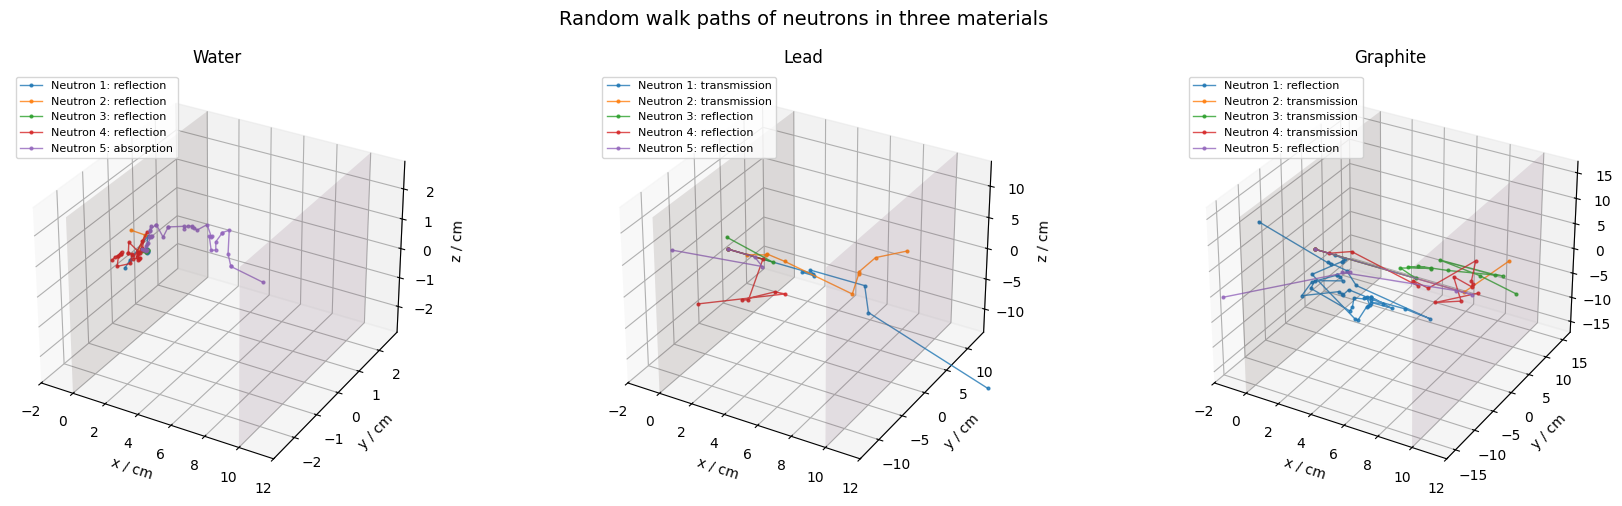

In [63]:
L = 10.0
num_paths = 5

materials_plot = {
    "Water": (Sigma_a_water, Sigma_s_water),
    "Lead": (Sigma_a_lead, Sigma_s_lead),
    "Graphite": (Sigma_a_graphite, Sigma_s_graphite),
}

# First generate and store paths
paths_by_material = {}

for material_name, (Sigma_a, Sigma_s) in materials_plot.items():
    paths = []

    for neutron_index in range(num_paths):
        outcome, path, total_distance = simulate_single_neutron_newer(
            L=L,
            Sigma_a=Sigma_a,
            Sigma_s=Sigma_s
        )

        paths.append((neutron_index + 1, outcome, path))

    paths_by_material[material_name] = paths


fig = plt.figure(figsize=(18, 5))

for i, (material_name, paths) in enumerate(paths_by_material.items(), start=1):
    ax = fig.add_subplot(1, 3, i, projection="3d")

    # Combine all paths for this material to find plotting range
    all_points = np.vstack([path for neutron_index, outcome, path in paths])

    yz_max = max(
        np.max(np.abs(all_points[:, 1])),
        np.max(np.abs(all_points[:, 2])),
        1.0
    )

    yz_limit = 1.2 * yz_max

    # Define slab boundary planes using this range
    y_plane = np.linspace(-yz_limit, yz_limit, 2)
    z_plane = np.linspace(-yz_limit, yz_limit, 2)
    Y_plane, Z_plane = np.meshgrid(y_plane, z_plane)

    # Plot paths
    for neutron_index, outcome, path in paths:
        ax.plot(
            path[:, 0],
            path[:, 1],
            path[:, 2],
            marker="o",
            markersize=2,
            linewidth=1,
            alpha=0.8,
            label=f"Neutron {neutron_index}: {outcome}"
        )

    # Plot boundary planes x = 0 and x = L
    X_left = np.zeros_like(Y_plane)
    X_right = L * np.ones_like(Y_plane)

    ax.plot_surface(X_left, Y_plane, Z_plane, alpha=0.12)
    ax.plot_surface(X_right, Y_plane, Z_plane, alpha=0.12)

    ax.set_xlim(-2, L + 2)
    ax.set_ylim(-yz_limit, yz_limit)
    ax.set_zlim(-yz_limit, yz_limit)

    ax.set_title(material_name)
    ax.set_xlabel("x / cm")
    ax.set_ylabel("y / cm")
    ax.set_zlabel("z / cm")

    ax.legend(fontsize=8, loc="upper left")

plt.suptitle("Random walk paths of neutrons in three materials", fontsize=14)
plt.tight_layout()
plt.show()

The visualisation cell sets L = 10 cm and plots five neutron paths for each material. The transparent planes mark x = 0 and x = L, so reflection and transmission can be read directly from the plotted trajectory. The individual paths are deliberately different from one another: each neutron samples a different sequence of free paths and scattering directions.

The plotted paths show why the final result must be treated statistically. A single neutron path is not representative of the material as a whole; it is only one possible history. The useful physical quantities are therefore the absorption, reflection and transmission fractions obtained from many neutron histories.

## 2.3 Quantifying scattering processes

For probability estimates, the code uses simulate_many_neutrons_vectorized rather than storing complete paths. This function keeps arrays of active neutron x positions and x-direction components. This is enough for slab transmission because the escape boundaries depend only on x.

The initial direction is +x, so directions_x starts as 1 for every neutron. After scattering, the code samples the new x-direction component uniformly from -1 to 1. This is equivalent to sampling $\cos\theta$ for an isotropic three-dimensional direction, but avoids storing the unused y and z components.

For a 10 cm slab, the notebook runs N = 10000 neutrons per simulation and repeats the simulation 10 times for each material. The reported counts and probabilities are means over these repeated runs:

$$
P_A = \frac{N_A}{N},\qquad P_R = \frac{N_R}{N},\qquad P_T = \frac{N_T}{N}.
$$

The uncertainty columns are the sample standard deviations of the 10 repeated probability estimates, calculated by repeat_simulation_with_errors.

In [64]:
def simulate_many_neutrons_vectorized(N, L, Sigma_a, Sigma_s):
    """
    Simulate N neutrons through a slab and calculate absorption,
    reflection and transmission rates.

    Parameters
    ----------
    N : int
        Number of neutrons to simulate.
    L : float
        Slab thickness in cm.
    Sigma_a : float
        Macroscopic absorption cross-section in cm^-1.
    Sigma_s : float
        Macroscopic scattering cross-section in cm^-1.
    max_steps : int
        Maximum number of steps allowed for each neutron.

    Returns
    -------
    counts : dict
        Number of neutrons for each outcome.
    probabilities : dict
        Probability of each outcome.
    The uncertainty is estimated outside this function by repeating the
    simulation and taking the standard deviation of the repeated probabilities.
    """

    Sigma_t = Sigma_a + Sigma_s
    mean_free_path = 1.0 / Sigma_t
    absorption_probability = Sigma_a / Sigma_t

    counts = {
        "absorption": 0,
        "reflection": 0,
        "transmission": 0
    }

    # Track only active neutrons.
    positions_x = np.zeros(N)
    directions_x = np.ones(N)

    while len(positions_x) > 0:

        positions_x += sample_exponential(mean_free_path, len(positions_x)) * directions_x

        reflected = positions_x < 0.0
        transmitted = positions_x > L

        counts["reflection"] += np.sum(reflected)
        counts["transmission"] += np.sum(transmitted)

        # For neutrons that are still inside the slab, determine absorption or scattering
        inside_mask = ~(reflected | transmitted)
        positions_x = positions_x[inside_mask]
        directions_x = directions_x[inside_mask]

        absorbed = np.random.uniform(0.0, 1.0, len(positions_x)) < absorption_probability
        counts["absorption"] += np.sum(absorbed)
        
        scattered = ~absorbed
        positions_x = positions_x[scattered]

        # For scattered neutrons, assign new isotropic directions and
        # keep only their x-direction components for 1D slab tracking.
        num_scattered = len(positions_x)
        directions_x = np.random.uniform(-1, 1, size=num_scattered)

    probabilities = {}

    for outcome, count in counts.items():
        p = count / N
        probabilities[outcome] = p

    return counts, probabilities

def repeat_simulation_with_errors(simulation_function, N_repeats=10, outcomes=None, result_keys=None, **simulation_kwargs):
    """
    Repeat a simulation several times and estimate errors from run-to-run scatter.

    This is used for the sections where the same Monte Carlo calculation is run
    10 times, then the mean values and standard deviations are reported.
    """

    repeated_results = [
        simulation_function(**simulation_kwargs)
        for _ in range(N_repeats)
    ]

    first_result = repeated_results[0]
    ddof = 1 if N_repeats > 1 else 0

    if isinstance(first_result, tuple):
        repeat_counts = [result[0] for result in repeated_results]
        repeat_probabilities = [result[1] for result in repeated_results]

        if outcomes is None:
            outcomes = list(repeat_probabilities[0].keys())

        mean_counts = {
            outcome: np.mean([counts[outcome] for counts in repeat_counts])
            for outcome in outcomes
        }

        mean_probabilities = {
            outcome: np.mean([probabilities[outcome] for probabilities in repeat_probabilities])
            for outcome in outcomes
        }

        uncertainties = {
            outcome: np.std(
                [probabilities[outcome] for probabilities in repeat_probabilities],
                ddof=ddof
            )
            for outcome in outcomes
        }

        return {
            "counts": mean_counts,
            "probabilities": mean_probabilities,
            "uncertainties": uncertainties,
            "all_counts": repeat_counts,
            "all_probabilities": repeat_probabilities
        }

    if result_keys is None:
        result_keys = [
            key for key in first_result
            if key != "L" and not key.endswith("_error")
        ]

    repeated_values = {
        key: np.array([result[key] for result in repeated_results])
        for key in result_keys
    }

    summary = {}
    if "L" in first_result:
        summary["L"] = first_result["L"]

    for key, values in repeated_values.items():
        summary[key] = np.mean(values, axis=0)
        summary[f"{key}_error"] = np.std(values, axis=0, ddof=ddof)

    summary["all_results"] = repeated_results

    return summary


,Material,N_A,N_R,N_T,Absorption rate,Absorption uncertainty,Reflection rate,Reflection uncertainty,Transmission rate,Transmission uncertainty
0,Water,1997.4,7972.0,30.6,0.19974,0.005071,0.79720,0.004927,0.00306,0.000412
1,Lead,1014.6,6185.5,2799.9,0.10146,0.002072,0.61855,0.003307,0.27999,0.003981
2,Graphite,79.7,6863.2,3057.1,0.00797,0.000821,0.68632,0.003692,0.30571,0.003766


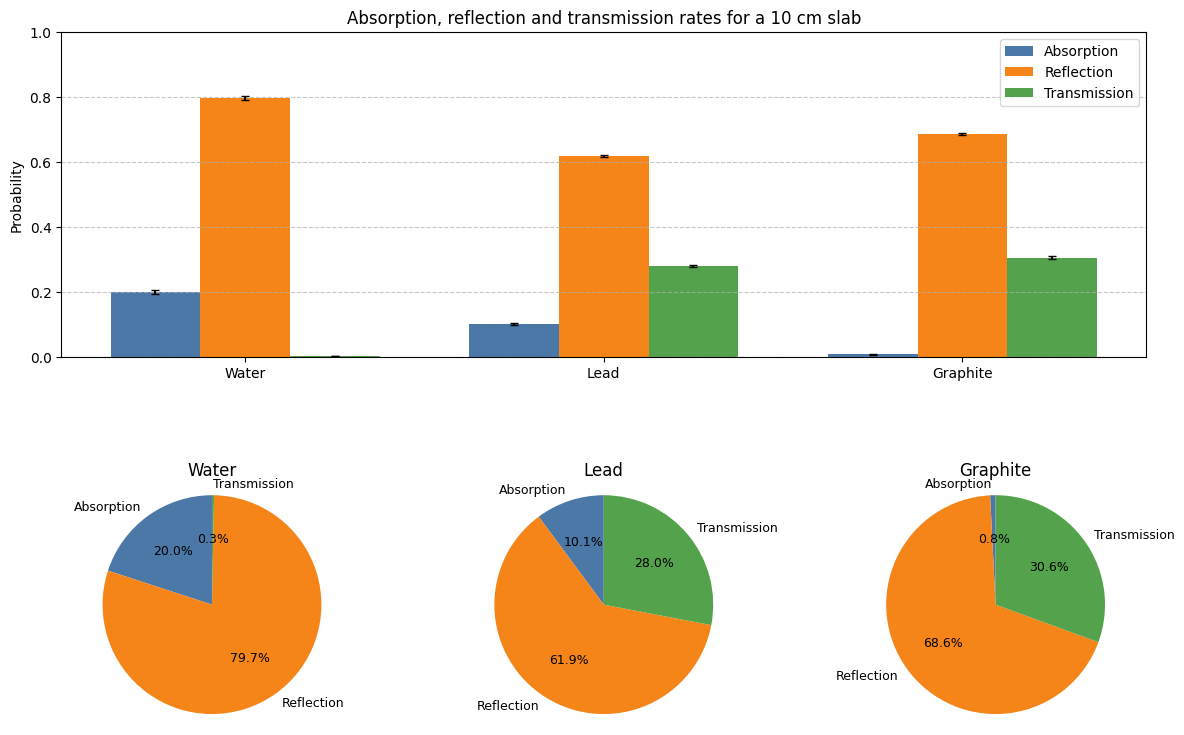

In [65]:
L = 10.0          # slab thickness in cm
N = 10000        # number of neutrons per run
N_repeats = 10   # run the simulation 10 times for uncertainty estimation

materials_simulation = {
    "Water": {
        "Sigma_a": Sigma_a_water,
        "Sigma_s": Sigma_s_water
    },
    "Lead": {
        "Sigma_a": Sigma_a_lead,
        "Sigma_s": Sigma_s_lead
    },
    "Graphite": {
        "Sigma_a": Sigma_a_graphite,
        "Sigma_s": Sigma_s_graphite
    }
}

outcomes = ["absorption", "reflection", "transmission"]
results_10cm = {}

for material_name, props in materials_simulation.items():
    results_10cm[material_name] = repeat_simulation_with_errors(
        simulate_many_neutrons_vectorized,
        N_repeats=N_repeats,
        outcomes=outcomes,
        N=N,
        L=L,
        Sigma_a=props["Sigma_a"],
        Sigma_s=props["Sigma_s"]
    )


rows = []

for material_name, result in results_10cm.items():
    counts = result["counts"]
    probabilities = result["probabilities"]
    uncertainties = result["uncertainties"]

    rows.append({
        "Material": material_name,

        "N_A": counts["absorption"],
        "N_R": counts["reflection"],
        "N_T": counts["transmission"],

        "Absorption rate": probabilities["absorption"],
        "Absorption uncertainty": uncertainties["absorption"],

        "Reflection rate": probabilities["reflection"],
        "Reflection uncertainty": uncertainties["reflection"],

        "Transmission rate": probabilities["transmission"],
        "Transmission uncertainty": uncertainties["transmission"]
    })

rates_table = pd.DataFrame(rows)
display(rates_table)


# Plot the outcome probabilities with error bars and pie charts.
materials = list(results_10cm.keys())
outcome_labels = [outcome.capitalize() for outcome in outcomes]
outcome_colors = ["#4C78A8", "#F58518", "#54A24B"]

x = np.arange(len(materials))
bar_width = 0.25

fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, height_ratios=[1.35, 1.0], hspace=0.45, wspace=0.30)
ax_bar = fig.add_subplot(gs[0, :])

for i, outcome in enumerate(outcomes):
    rates = [
        results_10cm[material]["probabilities"][outcome]
        for material in materials
    ]

    errors = [
        results_10cm[material]["uncertainties"][outcome]
        for material in materials
    ]

    ax_bar.bar(
        x + i * bar_width,
        rates,
        width=bar_width,
        yerr=errors,
        capsize=3,
        color=outcome_colors[i],
        label=outcome.capitalize()
    )

ax_bar.set_xticks(x + bar_width)
ax_bar.set_xticklabels(materials)
ax_bar.set_ylabel("Probability")
ax_bar.set_title("Absorption, reflection and transmission rates for a 10 cm slab")
ax_bar.legend()
ax_bar.grid(True, axis="y", linestyle="--", alpha=0.7)
ax_bar.set_ylim(0, 1)

for j, material in enumerate(materials):
    ax_pie = fig.add_subplot(gs[1, j])

    probabilities = [
        results_10cm[material]["probabilities"][outcome]
        for outcome in outcomes
    ]

    ax_pie.pie(
        probabilities,
        labels=outcome_labels,
        autopct="%1.1f%%",
        startangle=90,
        colors=outcome_colors,
        textprops={"fontsize": 9}
    )

    ax_pie.set_title(material)
    ax_pie.axis("equal")

plt.show()


For the 10 cm slab, the output table gives transmission probabilities of about 0.003 for water, 0.280 for lead and 0.306 for graphite. Water transmits very few neutrons because its large scattering cross-section causes many neutrons to be redirected back out of the slab. Graphite has the smallest absorption rate, about 0.008, because its macroscopic absorption cross-section is much smaller than those of water and lead.

The main conclusion from this table is that scattering, not just absorption, controls the transmitted neutron flux. Water is not the strongest absorber in the table, but it is the strongest scatterer, and this produces the lowest transmission. The bar chart and pie charts show the same pattern visually: reflection dominates for all three materials at 10 cm, while graphite is almost entirely a scattering/reflection material rather than an absorbing one.

## 2.4 Plotting variations with slab thickness

The thickness scan uses L_values = np.linspace(1.0, 20.0, 20), so the plotted slab thicknesses run from 1 cm to 20 cm. For each material and each thickness, scan_thickness calls simulate_many_neutrons_vectorized with N_scan = 10000 neutrons.

The whole thickness scan is then repeated 10 times using repeat_simulation_with_errors. The plotted values are the mean absorption, reflection and transmission probabilities, and the error bars are the standard deviations across those 10 repeated scans.

In [66]:
def scan_thickness(L_values, N, Sigma_a, Sigma_s):
    """
    Simulate neutron transport for a range of slab thicknesses.

    Parameters
    ----------
    L_values : array
        Array of slab thicknesses in cm.
    N : int
        Number of neutrons simulated for each thickness.
    Sigma_a : float
        Macroscopic absorption cross-section in cm^-1.
    Sigma_s : float
        Macroscopic scattering cross-section in cm^-1.
    max_steps : int
        Maximum number of steps per neutron.

    Returns
    -------
    results : dict
        Absorption, reflection and transmission probabilities and uncertainties.
    """

    absorption_rates = np.zeros(len(L_values))
    reflection_rates = np.zeros(len(L_values))
    transmission_rates = np.zeros(len(L_values))

    absorption_errors = np.zeros(len(L_values))
    reflection_errors = np.zeros(len(L_values))
    transmission_errors = np.zeros(len(L_values))

    for i, L in enumerate(L_values):
        _, probabilities = simulate_many_neutrons_vectorized(
            N=N,
            L=L,
            Sigma_a=Sigma_a,
            Sigma_s=Sigma_s,
        )

        absorption_rates[i] = probabilities["absorption"]
        reflection_rates[i] = probabilities["reflection"]
        transmission_rates[i] = probabilities["transmission"]
        

    return {
        "L": L_values,
        "absorption": absorption_rates,
        "reflection": reflection_rates,
        "transmission": transmission_rates,
        "absorption_error": absorption_errors,
        "reflection_error": reflection_errors,
        "transmission_error": transmission_errors,
    }


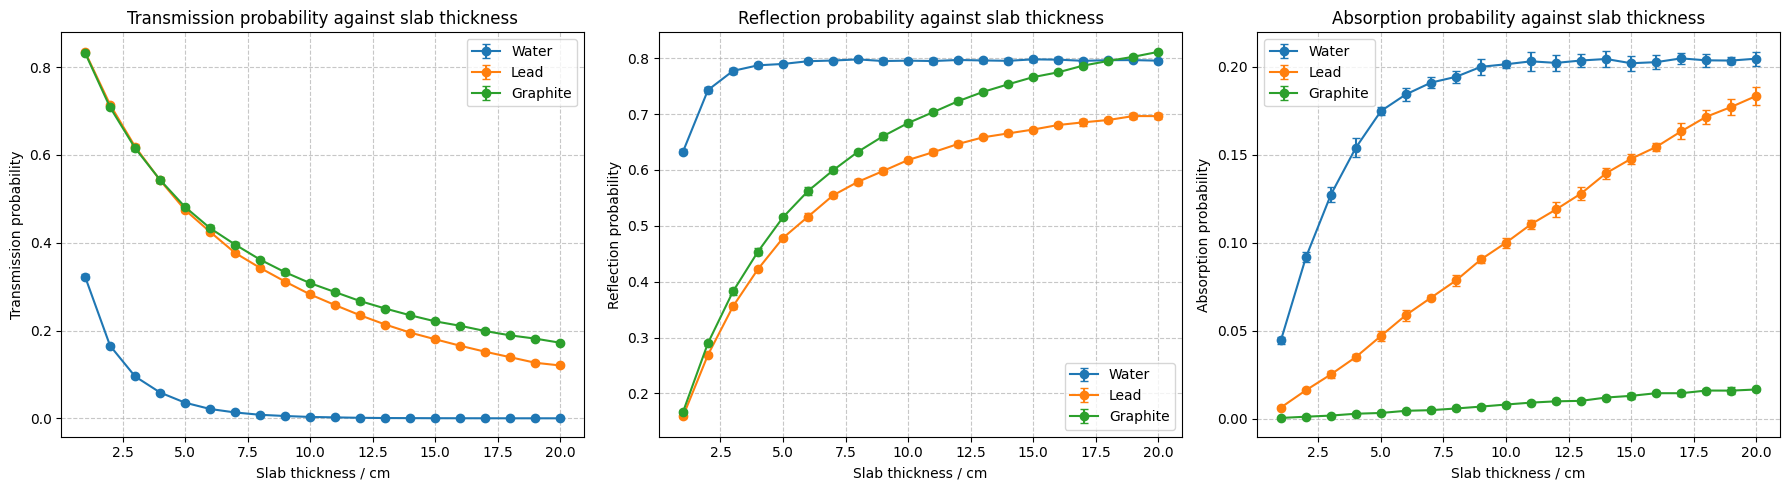

In [67]:
materials_simulation = {
    "Water": {
        "Sigma_a": Sigma_a_water,
        "Sigma_s": Sigma_s_water
    },
    "Lead": {
        "Sigma_a": Sigma_a_lead,
        "Sigma_s": Sigma_s_lead
    },
    "Graphite": {
        "Sigma_a": Sigma_a_graphite,
        "Sigma_s": Sigma_s_graphite
    }
}

L_values = np.linspace(1.0, 20.0, 20)
N_scan = 10000
N_repeats = 10

thickness_results = {}

for material_name, props in materials_simulation.items():
    thickness_results[material_name] = repeat_simulation_with_errors(
        scan_thickness,
        N_repeats=N_repeats,
        result_keys=["absorption", "reflection", "transmission"],
        L_values=L_values,
        N=N_scan,
        Sigma_a=props["Sigma_a"],
        Sigma_s=props["Sigma_s"]
    )
    

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_info = [
    ("transmission", "transmission_error", "Transmission probability", "Transmission probability against slab thickness"),
    ("reflection", "reflection_error", "Reflection probability", "Reflection probability against slab thickness"),
    ("absorption", "absorption_error", "Absorption probability", "Absorption probability against slab thickness"),
]



for ax, (rate_key, error_key, ylabel, title) in zip(axes, plot_info):
    for material_name, results in thickness_results.items():
        ax.errorbar(
            results["L"],
            results[rate_key],
            yerr=results[error_key],
            marker="o",
            capsize=3,
            label=material_name
        )

    ax.set_xlabel("Slab thickness / cm")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()


The plots show transmission falling as thickness increases. Water loses transmission fastest because its total cross-section is dominated by strong scattering. Lead and graphite retain higher transmission over this 1-20 cm range, but reflection still becomes more important as the slab becomes thicker. Absorption grows with thickness, especially for water and lead, but graphite remains weakly absorbing because $\Sigma_a$ is very small.

This behaviour is physically reasonable for a shielding layer. A thicker slab gives neutrons more opportunities to interact before reaching the far side, so the transmitted fraction decreases. The absorption and reflection curves do not simply grow in the same way for every material, because the final outcome depends on the competition between absorption probability and scattering direction after each collision.

## 2.5 Determining attenuation lengths from transmission rates

The fitted attenuation lengths in this section are obtained from the simulated transmission probabilities in the thickness scan. The code assumes that, over the fitted thickness range, the transmission can be approximated by

$$
T(L) = A e^{-L/\Lambda},
$$

where \Lambda is an effective transmission attenuation length. Taking logarithms gives

$$
\ln T = \ln A - \frac{L}{\Lambda}.
$$

The function fit_attenuation_length removes any zero-transmission points, calculates \ln T and its uncertainty using \sigma_{\ln T} = \sigma_T/T, and then performs a weighted linear polyfit. If the fitted slope is m, then

$$
\Lambda = -\frac{1}{m}.
$$

The printed results are approximately 1.89 cm for water, 9.06 cm for lead and 11.27 cm for graphite. These are effective transport attenuation lengths, not the absorption-only lengths from the material table, because scattering changes the probability of forward transmission.

In [68]:
def fit_attenuation_length(L, transmission_rates, transmission_errors):
    """
    Fit the attenuation length from transmission data.

    Parameters
    ----------
    L : array
        Array of slab thicknesses in cm.
    transmission_rates : array
        Array of transmission probabilities corresponding to each thickness.
    transmission_errors : array
        Array of uncertainties in the transmission probabilities.

    Returns
    -------
    lambda_fit : float
        Fitted attenuation length in cm.
    lambda_error : float
        Uncertainty in the fitted attenuation length.
    """

    # Filter out zero or negative transmission rates to avoid log issues
    valid = transmission_rates > 0
    L_valid = L[valid]
    T_valid = transmission_rates[valid]
    T_error_valid = transmission_errors[valid]

    log_T = np.log(T_valid)
    error_log_T = T_error_valid / T_valid

    fit, covariance = np.polyfit(
        L_valid,
        log_T,
        1,
        w=1.0 / error_log_T,
        cov=True
    )

    slope = fit[0]
    intercept = fit[1]

    slope_error = np.sqrt(covariance[0, 0])

    lambda_fit = -1.0 / slope
    lambda_error = slope_error / slope**2

    return lambda_fit, lambda_error, intercept, slope    

Water: attenuation length = 1.89 ± 0.03 cm
Lead: attenuation length = 9.06 ± 0.24 cm
Graphite: attenuation length = 11.27 ± 0.45 cm


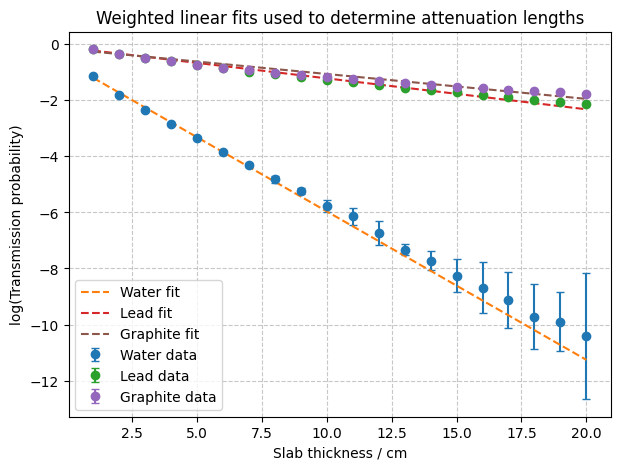

In [69]:
attenuation_results = {}

for material_name, results in thickness_results.items():
    attenuation_results[material_name] = fit_attenuation_length(
        results["L"],
        results["transmission"],
        results["transmission_error"]
    )

    att = attenuation_results[material_name][0]
    err = attenuation_results[material_name][1]

    print(f"{material_name}: attenuation length = {att:.2f} ± {err:.2f} cm")

plt.figure(figsize=(7, 5))

for material_name, result in attenuation_results.items():
    valid = thickness_results[material_name]["transmission"] > 0
    L_fit = thickness_results[material_name]["L"][valid]
    log_T = np.log(thickness_results[material_name]["transmission"][valid])
    error_log_T = thickness_results[material_name]["transmission_error"][valid] / thickness_results[material_name]["transmission"][valid]
    slope = attenuation_results[material_name][3]
    intercept = attenuation_results[material_name][2]

    L_curve = np.linspace(np.min(L_fit), np.max(L_fit), 200)
    log_T_curve = intercept + slope * L_curve

    plt.errorbar(
        L_fit,
        log_T,
        yerr=error_log_T,
        marker="o",
        linestyle="none",
        capsize=3,
        label=f"{material_name} data"
    )

    plt.plot(
        L_curve,
        log_T_curve,
        linestyle="--",
        label=f"{material_name} fit"
    )

plt.xlabel("Slab thickness / cm")
plt.ylabel("log(Transmission probability)")
plt.title("Weighted linear fits used to determine attenuation lengths")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

The fitted effective attenuation lengths are much shorter than the absorption-only attenuation lengths in the material table. For example, water has an absorption-only length of about 45 cm, but the transmission fit gives about 1.89 cm. This difference occurs because the transmission fit counts any neutron that fails to reach x = L as removed from the forward beam, including neutrons that are scattered backwards rather than absorbed.

Therefore, the fitted $\Lambda$ values should be interpreted as transport attenuation lengths for this slab geometry, not as pure absorption lengths. They are still useful because they describe how quickly the transmitted neutron fraction decreases with shielding thickness.

## Stretch yourself: Woodcock method for two adjacent slabs

The stretch section implements Woodcock tracking for two adjacent 10 cm slabs. The first slab occupies 0 < x < 10 cm and the second slab occupies 10 < x < 20 cm. Instead of treating the boundary as a special case for sampling the next collision distance, the code samples trial collisions using a majorant cross-section:

$$
\Sigma_M = \max(\Sigma_{t,1}, \Sigma_{t,2}).
$$

At a trial collision, the local material is found from the neutron's x position. The collision is accepted as a real collision with probability $\Sigma_t(x)/\Sigma_M$. If it is rejected, it is a virtual collision and the neutron continues in the same direction. If it is accepted, the code then decides absorption using $\Sigma_a(x)/\Sigma_t(x)$, otherwise the neutron scatters and receives a new x-direction component.

In [70]:
materials_woodcock = {
    "Water": {
        "Sigma_a": Sigma_a_water,
        "Sigma_s": Sigma_s_water
    },
    "Lead": {
        "Sigma_a": Sigma_a_lead,
        "Sigma_s": Sigma_s_lead
    },
    "Graphite": {
        "Sigma_a": Sigma_a_graphite,
        "Sigma_s": Sigma_s_graphite
    }
}


def simulate_two_slab_woodcock(N, first_material, second_material, slab_thickness=10.0):
    """
    Simulate neutron transport through two adjacent slabs using Woodcock tracking.

    The first slab occupies 0 < x < slab_thickness and the second slab occupies
    slab_thickness < x < 2 * slab_thickness. Neutrons enter at x = 0 in the +x
    direction. A Woodcock majorant cross-section is used across both materials,
    so material boundaries do not need special sampling logic.
    """

    first = materials_woodcock[first_material]
    second = materials_woodcock[second_material]

    Sigma_a_first = first["Sigma_a"]
    Sigma_s_first = first["Sigma_s"]
    Sigma_t_first = Sigma_a_first + Sigma_s_first

    Sigma_a_second = second["Sigma_a"]
    Sigma_s_second = second["Sigma_s"]
    Sigma_t_second = Sigma_a_second + Sigma_s_second

    Sigma_majorant = max(Sigma_t_first, Sigma_t_second)
    total_thickness = 2.0 * slab_thickness

    counts = {
        "absorption": 0,
        "reflection": 0,
        "transmission": 0
    }

    positions_x = np.zeros(N)
    directions_x = np.ones(N)

    while len(positions_x) > 0:
        trial_step = sample_exponential(1.0 / Sigma_majorant, len(positions_x))
        positions_x += trial_step * directions_x

        reflected = positions_x < 0.0
        transmitted = positions_x > total_thickness

        counts["reflection"] += np.sum(reflected)
        counts["transmission"] += np.sum(transmitted)

        inside_mask = ~(reflected | transmitted)
        positions_x = positions_x[inside_mask]
        directions_x = directions_x[inside_mask]

        in_first_layer = positions_x < slab_thickness
        Sigma_a_local = np.where(in_first_layer, Sigma_a_first, Sigma_a_second)
        Sigma_t_local = np.where(in_first_layer, Sigma_t_first, Sigma_t_second)

        real_collision = np.random.uniform(0.0, 1.0, len(positions_x)) < (Sigma_t_local / Sigma_majorant)

        absorbed = np.zeros(len(positions_x), dtype=bool)
        if np.any(real_collision):
            real_indices = np.where(real_collision)[0]
            absorbed_at_real = np.random.uniform(0.0, 1.0, len(real_indices)) < (
                Sigma_a_local[real_indices] / Sigma_t_local[real_indices]
            )
            absorbed[real_indices] = absorbed_at_real

        counts["absorption"] += np.sum(absorbed)

        surviving = ~absorbed
        positions_x = positions_x[surviving]
        directions_x = directions_x[surviving]

        real_survivors = real_collision[surviving]
        num_real_scattered = np.sum(real_survivors)

        if num_real_scattered > 0:
            directions_x[real_survivors] = np.random.uniform(-1, 1, size=num_real_scattered)

    probabilities = {}

    for outcome, count in counts.items():
        p = count / N
        probabilities[outcome] = p

    return counts, probabilities

#np.random.seed(20762)

woodcock_outcomes = ["absorption", "reflection", "transmission"]

N_validation = 20000
N_validation_repeats = 10
validation_rows = []

homogeneous_results = {}

for material_name, props in materials_woodcock.items():
    homogeneous_results[material_name] = repeat_simulation_with_errors(
        simulate_many_neutrons_vectorized,
        N_repeats=N_validation_repeats,
        outcomes=woodcock_outcomes,
        N=N_validation,
        L=20.0,
        Sigma_a=props["Sigma_a"],
        Sigma_s=props["Sigma_s"]
    )

    woodcock_result = repeat_simulation_with_errors(
        simulate_two_slab_woodcock,
        N_repeats=N_validation_repeats,
        outcomes=woodcock_outcomes,
        N=N_validation,
        first_material=material_name,
        second_material=material_name,
        slab_thickness=10.0
    )

    homogeneous_probabilities = homogeneous_results[material_name]["probabilities"]
    homogeneous_uncertainties = homogeneous_results[material_name]["uncertainties"]
    woodcock_probabilities = woodcock_result["probabilities"]
    woodcock_uncertainties = woodcock_result["uncertainties"]

    combined_error = np.sqrt(
        homogeneous_uncertainties["transmission"]**2
        + woodcock_uncertainties["transmission"]**2
    )

    if combined_error > 0:
        z_score = (
            np.abs(woodcock_probabilities["transmission"]
            - homogeneous_probabilities["transmission"])
        ) / combined_error
    else:
        z_score = np.nan

    validation_rows.append({
        "Material": material_name,
        "Direct 20 cm transmission": homogeneous_probabilities["transmission"],
        "Woodcock 10 cm + 10 cm transmission": woodcock_probabilities["transmission"],
        "Combined uncertainty": combined_error,
        "z-score": z_score
    })

validation_table = pd.DataFrame(validation_rows)
validation_table

,Material,Direct 20 cm transmission,Woodcock 10 cm + 10 cm transmission,Combined uncertainty,z-score
0,Water,0.000045,0.000020,0.000061,0.411306
1,Lead,0.117475,0.118835,0.003351,0.405801
2,Graphite,0.172020,0.171680,0.004713,0.072141


The validation step compares the Woodcock method with the earlier homogeneous-slab simulation. For each material, the code compares direct transport through one 20 cm slab with Woodcock transport through two adjacent 10 cm slabs made of the same material. Both calculations use N_validation = 20000 neutrons and 10 repeated runs.

The transmission values agree within the combined uncertainty, with z-scores well below 1 for water, lead and graphite. This means that the difference between the direct simulation and the Woodcock simulation is smaller than the expected Monte Carlo scatter. The validation therefore supports the use of the Woodcock method for the mixed-material two-slab calculation.

,Slabs,Absorption,Reflection,Transmission,Transmission uncertainty,Probability sum
0,Lead then Graphite,0.144968,0.711686,0.143346,0.001261,1.0
1,Graphite then Lead,0.070504,0.788354,0.141142,0.000943,1.0


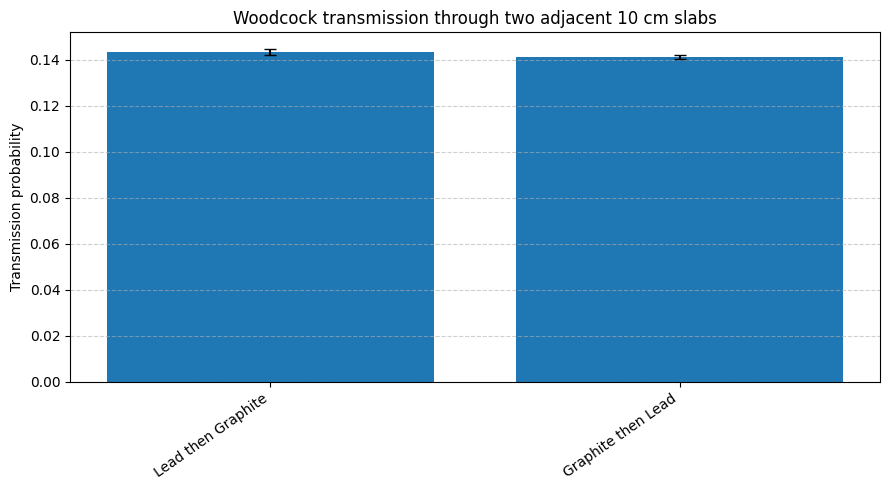

In [71]:
materials_woodcock_new = {
    "Lead": {
        "Sigma_a": Sigma_a_lead,
        "Sigma_s": Sigma_s_lead
    },
    "Graphite": {
        "Sigma_a": Sigma_a_graphite,
        "Sigma_s": Sigma_s_graphite
    }
}

N_stretch = 50000
N_stretch_repeats = 10
stretch_rows = []

for first_material in materials_woodcock_new:
    for second_material in materials_woodcock_new:
        if first_material == second_material:
            continue

        result = repeat_simulation_with_errors(
            simulate_two_slab_woodcock,
            N_repeats=N_stretch_repeats,
            outcomes=woodcock_outcomes,
            N=N_stretch,
            first_material=first_material,
            second_material=second_material,
            slab_thickness=10.0
        )
        probabilities = result["probabilities"]
        uncertainties = result["uncertainties"]

        stretch_rows.append({
            "Slabs": f"{first_material} then {second_material}",
            "Absorption": probabilities["absorption"],
            "Reflection": probabilities["reflection"],
            "Transmission": probabilities["transmission"],
            "Transmission uncertainty": uncertainties["transmission"],
            "Probability sum": sum(probabilities.values())
        })

stretch_results_table = pd.DataFrame(stretch_rows)
display(stretch_results_table)

plt.figure(figsize=(9, 5))
plt.bar(
    stretch_results_table["Slabs"],
    stretch_results_table["Transmission"],
    yerr=stretch_results_table["Transmission uncertainty"],
    capsize=4
)
plt.ylabel("Transmission probability")
plt.title("Woodcock transmission through two adjacent 10 cm slabs")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()




The mixed-material calculation is then performed for lead followed by graphite and graphite followed by lead. The code uses N_stretch = 50000 neutrons and 10 repeated runs for each ordering. The transmission probabilities are close, about 0.143 for lead-then-graphite and 0.141 for graphite-then-lead, but the absorption and reflection probabilities differ more noticeably.

This result is plausible because both slabs have the same total thickness and the same two materials, so the overall transmission is similar. However, the order can still affect the internal history of the neutron: a neutron entering lead first has a higher chance of early absorption, while a neutron entering graphite first has a higher chance of being scattered before reaching the lead. This is why absorption and reflection change more than transmission.

## Runtime check

The final timing cell reports the runtime from the start of the notebook. The current run gives a runtime of about 15 s, which is below the 45 s proficient threshold in the project brief. This is achieved by using full three-dimensional path storage only for a few visual examples, while the repeated statistical calculations track only the x coordinate and x-direction component.

In [72]:
runtime = time.perf_counter() - start_time
print(f"Notebook runtime: {runtime:.2f} s")

Notebook runtime: 15.21 s


## Conclusion

The notebook builds the neutron transport simulation from validated sampling components. The uniform generator behaves correctly in one-dimensional histograms and three-dimensional point clouds, while the RANDSSP comparison demonstrates why spectral testing is important. The exponential sampler is validated by the absorption-only water calculation, giving 45.01 +- 0.12 cm compared with the theoretical 44.97 cm.

In the full scattering simulation, transmission is controlled by both absorption and direction changes. For a 10 cm slab, water has very low transmission because its scattering is strong, while lead and graphite transmit a larger fraction. Graphite absorbs very little, so most non-transmitted graphite neutrons are reflected rather than absorbed.

The thickness scan from 1 cm to 20 cm shows decreasing transmission for all materials. Fitting log transmission gives effective attenuation lengths of about 1.89 cm for water, 9.06 cm for lead and 11.27 cm for graphite. These are shorter than the absorption-only lengths because they include scattering out of the forward direction.

The Woodcock extension is validated against direct homogeneous 20 cm slab simulations and then applied to lead-graphite two-slab systems. The probability sums are conserved and the repeated-run uncertainties give a quantitative check on the reliability of the results. Overall, the results show that neutron shielding performance depends not only on absorption strength, but also on how strongly a material scatters neutrons away from the forward direction.